# CIC IIoT 2025 - EDA, Cleaning, Preprocessing & Feature Selection

**Dataset**: CIC IIoT 2025 "DataSense" - Canadian Institute for Cybersecurity (CIC), University of New Brunswick  
**Paper**: Firouzi et al. (2025), *DataSense: A Real-Time Sensor-Based Benchmark Dataset for Attack Analysis in IIoT*, MDPI. CC BY 4.0.  
**Time window**: 1-second aggregation (highest resolution available)  
**Task**: Multiclass classification - 8 classes: Benign, BruteForce, DDoS, DoS, Malware, MitM, Recon, Web
---
**Team members**: 
- Abdullah Almunayae (s2252100004@aasu.edu.kw)
- Bader Botaiban (s2252100013@aasu.edu.kw)

The CIC IIoT 2025 dataset captures real network traffic from physical IoT devices in a controlled lab environment. Each row represents one second of aggregated traffic from a device, described by 71 numerical statistics - things like average packet size, TCP SYN flag counts, and inter-arrival time variance.

This notebook walks through the full data preparation pipeline, step by step:

1. **Load & Explore** - understand what we're working with before changing anything
2. **Clean** - remove duplicates and metadata columns that aren't useful as features
3. **Encode & Split** - convert labels to numbers, then split train/test *before* any fitting
4. **Scale & Balance** - normalize features and fix class imbalance, using training data only
5. **Select Features** - compare three methods (Chi-Square, PCA-guided, Random Forest Importance)

The ordering of steps 3-5 is intentional and important. Fitting any transformer on the full dataset before splitting leaks test-set information into the training process, thus producing results that look better than they really are. Everything here is done the correct way.

## 1. Setup

Standard imports plus two path variables at the top.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# == DATA PATHS ========================================================
ATTACK_PATH = '/kaggle/input/datasets/baderbotaiban/cic-iiot-2025-datasense-csv-mirror/cic-iiot-2025/cic-iiot-2025/attack_data/attack_samples_1sec.csv'
BENIGN_PATH  = '/kaggle/input/datasets/baderbotaiban/cic-iiot-2025-datasense-csv-mirror/cic-iiot-2025/cic-iiot-2025/benign_data/benign_samples_1sec.csv'
# ======================================================================

RANDOM_STATE = 42
K_FEATURES   = 15
print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading

Attack and benign traffic are stored in separate CSVs. We load both and concatenate them into one DataFrame. The label columns (`label1`, `label2`) come from the original files and tell us what type of traffic each row represents.

In [2]:
attack = pd.read_csv(ATTACK_PATH)
benign = pd.read_csv(BENIGN_PATH)
df = pd.concat([attack, benign], ignore_index=True)

print(f'Attack rows : {len(attack):>8,}')
print(f'Benign rows : {len(benign):>8,}')
print(f'Total rows  : {len(df):>8,}')
print(f'Columns     : {df.shape[1]}')

Attack rows :   90,391
Benign rows :  136,800
Total rows  :  227,191
Columns     : 94


## 3. Exploratory Data Analysis (EDA)

Before writing a single line of preprocessing code, we look at the data. Good EDA prevents wasted effort as it tells us what's actually there versus what we assumed. This section answers four questions:

- What are the column types, and which ones are actually usable features?
- Are there missing values, duplicates, or infinite numbers that need handling?
- How are the 8 classes distributed ? Is the dataset balanced?
- How correlated are the features, and can we see visual patterns by attack type?

### 3.1 Column Types

The dataset has 94 total columns. Some are numeric traffic statistics (what we want to model with), some are our classification labels, and some are string metadata like device MAC addresses and IP lists which are identifiers, not features. We need to know what we have before deciding what to keep.

In [3]:
string_cols  = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f'Numeric columns : {len(numeric_cols)}')
print(f'String columns  : {len(string_cols)}')
print()
print('String columns (to be inspected for labels vs metadata):')
for c in string_cols:
    print(f'  {c}')

Numeric columns : 71
String columns  : 23

String columns (to be inspected for labels vs metadata):
  device_name
  device_mac
  label_full
  label1
  label2
  label3
  label4
  timestamp
  timestamp_start
  timestamp_end
  log_data-types
  network_ips_all
  network_ips_dst
  network_ips_src
  network_macs_all
  network_macs_dst
  network_macs_src
  network_ports_all
  network_ports_dst
  network_ports_src
  network_protocols_all
  network_protocols_dst
  network_protocols_src


### 3.2 Data Quality Check - Missing Values, Duplicates, Infinite Values

Three of the most common problems in real-world datasets. If any are present, they'll cause silent errors or biased models. We check all three upfront so we know exactly what cleaning is needed or whether none is.

In [4]:
nulls = df.isnull().sum()
dupes = df.duplicated().sum()
infs  = np.isinf(df[numeric_cols]).sum().sum()

print(f'Missing values  : {nulls.sum():,}')
print(f'Duplicate rows  : {dupes:,}')
print(f'Infinite values : {infs:,}')
print()
print('Conclusion: No imputation or deduplication required.')

Missing values  : 0
Duplicate rows  : 0
Infinite values : 0

Conclusion: No imputation or deduplication required.


**Finding**: The dataset is complete; no missing values, no duplicate rows, no infinite numbers. This is unusually clean for a real network capture dataset. We document it explicitly because the absence of a cleaning step is worth stating as much as the presence of one; it confirms no imputation or outlier removal is needed.

### 3.3 Class Distribution - label2 (Multiclass Target)

IoT attack datasets are almost always imbalanced; normal network operation generates far more traffic than any attack. We need to know *how severe* the imbalance is, because a model trained on imbalanced data will be biased toward the majority class. The distribution also tells us which attack types are rare and will need special handling during training.

In [5]:
label2_counts = df['label2'].value_counts().sort_values(ascending=False)
print('Class distribution (label2):')
print(label2_counts.to_string())
print()
majority = label2_counts.iloc[0]
minority = label2_counts.iloc[-1]
print(f'Imbalance ratio: {majority / minority:.1f}x  '
      f'({label2_counts.index[0]} vs {label2_counts.index[-1]})')

Class distribution (label2):
label2
benign        136800
recon          33648
dos            18420
ddos           18056
mitm            8062
malware         7541
web             2796
bruteforce      1868

Imbalance ratio: 73.2x  (benign vs bruteforce)


**Finding**: The class imbalance is severe. Benign traffic has 136,800 samples; BruteForce has only 1,868 which is a **73× ratio**. A naive classifier that always predicts "benign" would be right ~60% of the time without learning anything. We address this in Section 5.4 by undersampling the training set to 1,868 samples per class (11,952 total), giving the model an equal opportunity to learn all attack types.

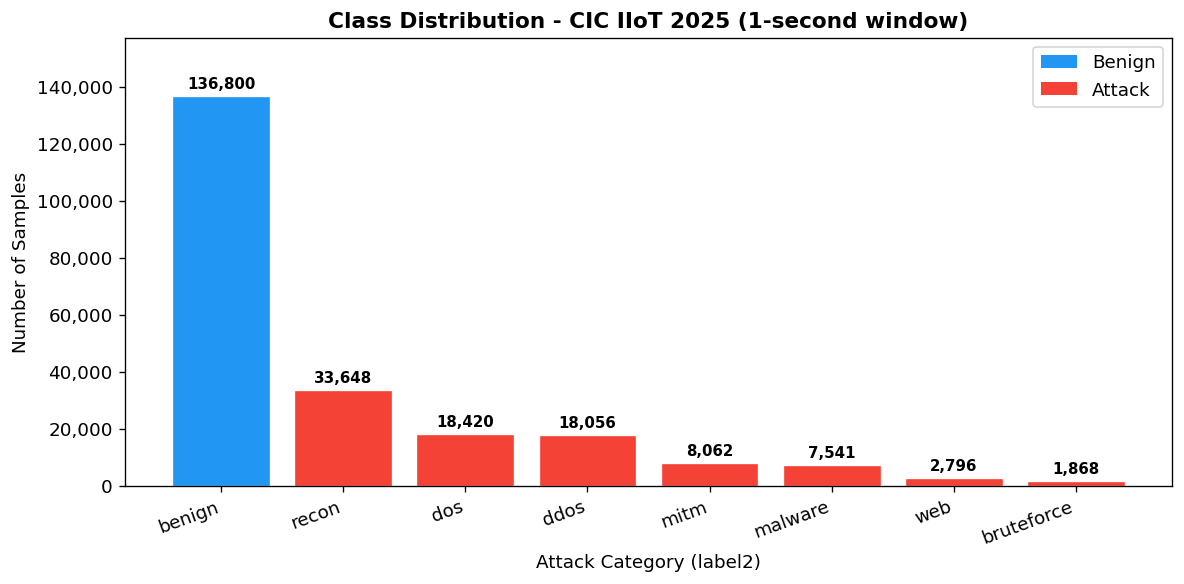

Severe class imbalance: benign dominates with 73x more samples than bruteforce.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2196F3' if c == 'benign' else '#F44336' for c in label2_counts.index]
bars = ax.bar(label2_counts.index, label2_counts.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, label2_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Class Distribution - CIC IIoT 2025 (1-second window)', fontsize=13, fontweight='bold')
ax.set_xlabel('Attack Category (label2)', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, label2_counts.max() * 1.15)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Benign'),
                   Patch(facecolor='#F44336', label='Attack')]
ax.legend(handles=legend_elements, loc='upper right')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('class_distribution_label2.png', bbox_inches='tight')
plt.show()
print('Severe class imbalance: benign dominates with 73x more samples than bruteforce.')

### 3.4 Correlation Heatmap - Top 20 Most Inter-Correlated Features

Many network traffic statistics move together naturally: average, max, and min packet size all inflate during the same burst of traffic. High correlation between features isn't harmful for tree-based models, but it's useful to see the structure; it tells us which features carry redundant information, and helps explain why feature selection methods that account for redundancy (like PCA and RFR) tend to outperform simpler filtering approaches.

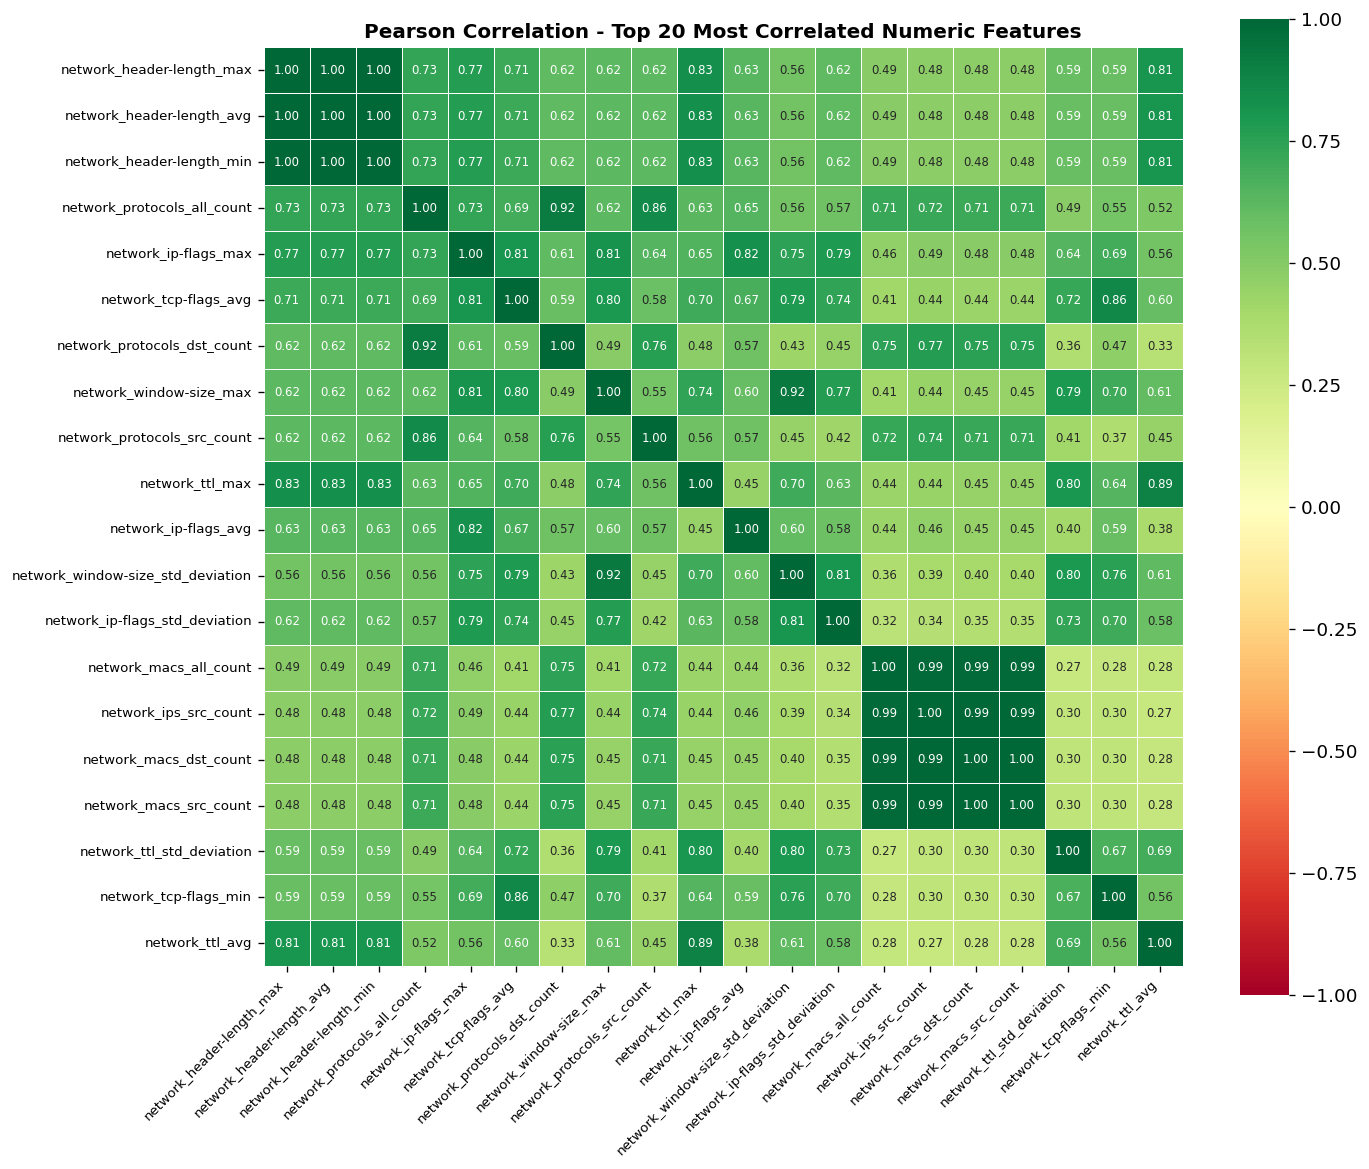

Highly correlated feature clusters visible (e.g., packet size avg/max/min/std).
PCA and RFR handle correlated features automatically.


In [7]:
# Select top 20 features with highest mean absolute correlation (excluding self-correlation)
corr_matrix = df[numeric_cols].corr().abs() - np.eye(len(numeric_cols))
top20 = corr_matrix.mean().nlargest(20).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df[top20].corr(),
    ax=ax,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.4,
    square=True
)
ax.set_title('Pearson Correlation - Top 20 Most Correlated Numeric Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Highly correlated feature clusters visible (e.g., packet size avg/max/min/std).')
print('PCA and RFR handle correlated features automatically.')

**Finding**: Several feature clusters are highly correlated as packet size statistics (avg, max, min, std) tend to move together, as do various TCP flag counts during the same attack burst. This is expected: during a DDoS flood, all packet volume measurements inflate simultaneously. Feature selection methods like RFR handle this naturally by picking the single most informative representative from each correlated group, rather than including all of them redundantly.

### 3.5 Feature Distributions by Attack Category

Box plots let us see, at a glance, whether a feature separates attack types. If a feature's box for DDoS sits far above its box for Benign, that feature is likely to be selected by any feature selector as it carries genuine discriminative signal. We look at four features that we expect to vary meaningfully across attack categories based on domain knowledge of how these attacks work.

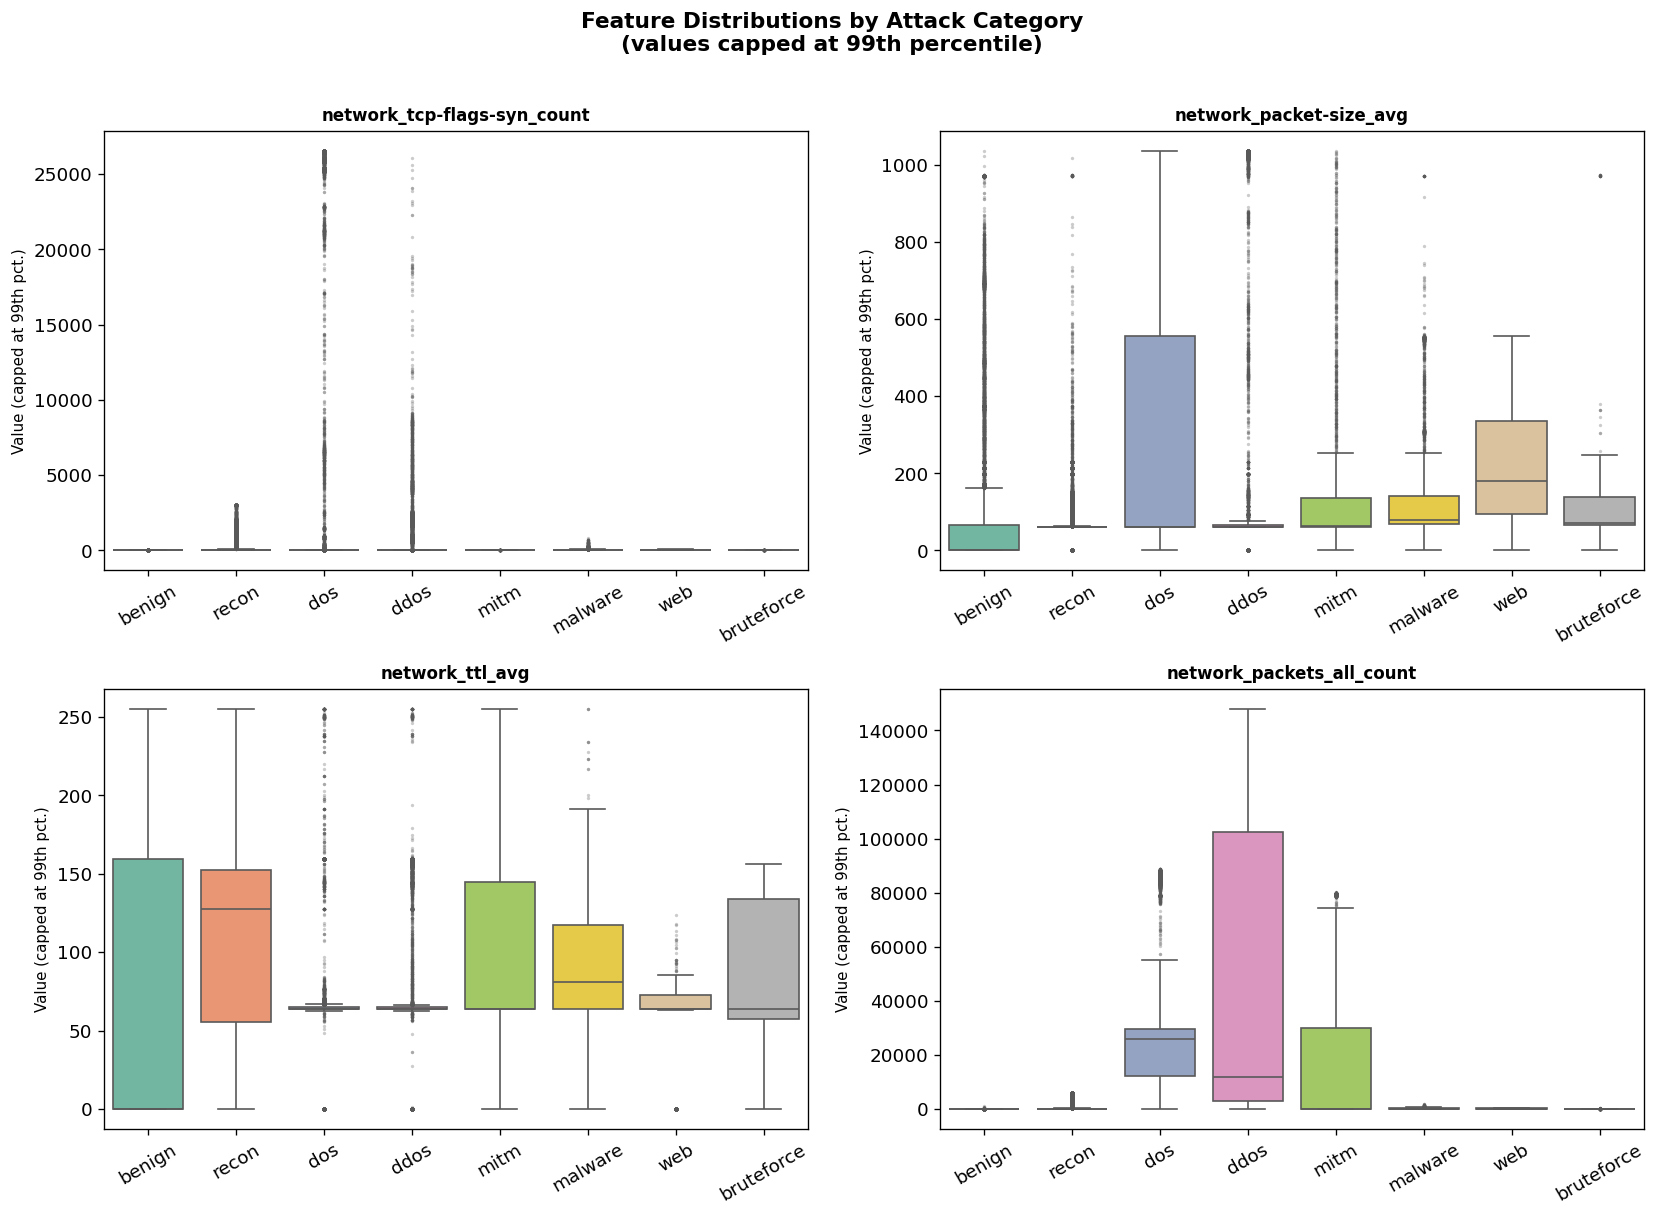

SYN count and packet count are strong discriminators between DDoS/DoS and Benign traffic.


In [8]:
# 4 representative features that distinguish attack types
features_to_plot = [
    'network_tcp-flags-syn_count',
    'network_packet-size_avg',
    'network_ttl_avg',
    'network_packets_all_count'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

label_order = label2_counts.index.tolist()
palette = sns.color_palette('Set2', len(label_order))

for ax, feat in zip(axes, features_to_plot):
    # Cap extreme outliers at 99th percentile for readability
    cap = df[feat].quantile(0.99)
    plot_df = df[df[feat] <= cap][['label2', feat]].copy()

    sns.boxplot(
        data=plot_df,
        x='label2', y=feat,
        order=label_order,
        palette=palette,
        ax=ax,
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3}
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Value (capped at 99th pct.)', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Feature Distributions by Attack Category\n(values capped at 99th percentile)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_boxplots.png', bbox_inches='tight')
plt.show()
print('SYN count and packet count are strong discriminators between DDoS/DoS and Benign traffic.')

**Finding**: SYN count and total packet count are strong visual separators as DDoS and DoS traffic show dramatically elevated values compared to Benign or Recon traffic. Average packet size shows subtler differences across categories. TTL varies because different attack tools use different default TTL values. These patterns confirm that network traffic statistics carry genuine discriminative signal for attack detection; the feature selection step in Section 6 should have clear information to work with.

## 4. Cleaning

Two things to handle here:

1. **Duplicate rows** - identical records that would let a model memorize specific examples rather than learning the underlying pattern. They also artificially inflate the size of the training set.
2. **Metadata columns** - the 21 string columns (device names, MAC addresses, IP lists, timestamps) are identifiers, not features. A model trained on these would learn *which device* generated traffic, not *what the traffic looks like* which is useless for detecting attacks on unseen devices.

### 4.1 Remove Duplicate Rows

In [9]:
before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
print(f'Rows before drop_duplicates : {before:,}')
print(f'Rows removed                : {removed:,}')
print(f'Rows after                  : {len(df):,}')

Rows before drop_duplicates : 227,191
Rows removed                : 0
Rows after                  : 227,191


### 4.2 Drop Metadata String Columns

Of the 23 string columns, two are our labels (`label1`, `label2`) and we keep those. The remaining 21 are metadata: device names, MAC addresses, IP address lists, port lists, timestamps, and protocol names. These are stored as Python list strings (e.g., `"['192.168.1.1', '10.0.0.2']"`) and identify *which* device generated the traffic, not *how* it behaved. We drop them so the model learns traffic patterns, not device identities.

In [10]:
# Identify label columns to keep and metadata string columns to drop
LABEL_COLS = ['label1', 'label2']

# All string/object columns that are NOT label columns are metadata (device IDs,
# timestamps, IP/MAC/port lists stored as Python list strings) → drop them
string_cols_current = df.select_dtypes(include=['object']).columns.tolist()
meta_cols = [c for c in string_cols_current if c not in LABEL_COLS]

print(f'Metadata columns to drop ({len(meta_cols)}):')
for c in meta_cols:
    print(f'  {c}')

df = df.drop(columns=meta_cols)
print(f'\nDataFrame shape after dropping metadata: {df.shape}')
print(f'Remaining columns: {df.shape[1]}  '
      f'({df.shape[1] - 2} numeric features + label1 + label2)')

Metadata columns to drop (21):
  device_name
  device_mac
  label_full
  label3
  label4
  timestamp
  timestamp_start
  timestamp_end
  log_data-types
  network_ips_all
  network_ips_dst
  network_ips_src
  network_macs_all
  network_macs_dst
  network_macs_src
  network_ports_all
  network_ports_dst
  network_ports_src
  network_protocols_all
  network_protocols_dst
  network_protocols_src

DataFrame shape after dropping metadata: (227191, 73)
Remaining columns: 73  (71 numeric features + label1 + label2)


### 4.3 Final Data Quality Verification

A quick sanity check after cleaning to confirm there are no nulls, infinities, or duplicates remaining before we hand the data off to preprocessing.

In [11]:
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

print(f'Missing values  : {df[feature_cols].isnull().sum().sum():,}')
print(f'Infinite values : {np.isinf(df[feature_cols]).sum().sum():,}')
print(f'Duplicate rows  : {df.duplicated().sum():,}')
print()
print(f'Feature columns : {len(feature_cols)}')
print('Sample feature names:')
for c in feature_cols[:8]:
    print(f'  {c}')

Missing values  : 0
Infinite values : 0
Duplicate rows  : 79,755

Feature columns : 71
Sample feature names:
  log_data-ranges_avg
  log_data-ranges_max
  log_data-ranges_min
  log_data-ranges_std_deviation
  log_data-types_count
  log_interval-messages
  log_messages_count
  network_fragmentation-score


## 5. Preprocessing

The order of operations here is deliberate:

```
Load → Clean → Encode Labels → Split 80/20 → Scale → Balance → Feature Selection
```

**Why split before scaling?**  
`StandardScaler` learns the mean and standard deviation of whatever data you give it. If you fit it on the full dataset, it learns from the test set too as the scaler's parameters are contaminated by test-set statistics before the model ever sees them. This is called **data leakage**, and it makes test results look artificially better than they'd be on truly unseen data. By splitting first and fitting the scaler only on training data, the test set stays genuinely unseen until evaluation.

**Why balance after splitting?**  
`RandomUnderSampler` removes rows to equalize class counts. Applying it to the full dataset before splitting can accidentally place related rows in both train and test sets, or distort the test set's natural class distribution. We apply it to the training set only, then evaluate against the unmodified test set which reflects the class distribution the model will actually encounter in deployment.

### 5.1 Label Encoding

Machine learning models work with numbers, not strings. `LabelEncoder` maps each class name to an integer (alphabetically assigned). We print the mapping so it's always clear what each number represents; important for interpreting confusion matrices and predictions later.

In [12]:
le = LabelEncoder()
y = le.fit_transform(df['label2'])
X = df[feature_cols].copy()

print('Label encoding (label2: multiclass):')
for code, label in enumerate(le.classes_):
    count = (y == code).sum()
    print(f'  {code} → {label:<15}  ({count:>7,} samples)')

Label encoding (label2: multiclass):
  0 → benign           (136,800 samples)
  1 → bruteforce       (  1,868 samples)
  2 → ddos             ( 18,056 samples)
  3 → dos              ( 18,420 samples)
  4 → malware          (  7,541 samples)
  5 → mitm             (  8,062 samples)
  6 → recon            ( 33,648 samples)
  7 → web              (  2,796 samples)


### 5.2 Train / Test Split: 80% Train, 20% Test

We split *before* any scaling, balancing, or feature selection. The `stratify=y` argument ensures all 8 classes are proportionally represented in both sets; critical here because of the severe class imbalance. Without stratification, the rarest class (BruteForce, ~1,868 samples) might be randomly over/under-represented in one split.

In [13]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw  = X_test_raw.reset_index(drop=True)

print(f'Train set : {X_train_raw.shape[0]:>7,} rows  ({X_train_raw.shape[0]/len(X)*100:.0f}%)')
print(f'Test set  : {X_test_raw.shape[0]:>7,} rows  ({X_test_raw.shape[0]/len(X)*100:.0f}%)')
print()
print('Class distribution in train set:')
train_dist = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts()
print(train_dist.to_string())
print()
print('Class distribution in test set:')
test_dist = pd.Series(y_test).map(dict(enumerate(le.classes_))).value_counts()
print(test_dist.to_string())

Train set : 181,752 rows  (80%)
Test set  :  45,439 rows  (20%)

Class distribution in train set:
benign        109439
recon          26918
dos            14736
ddos           14445
mitm            6450
malware         6033
web             2237
bruteforce      1494

Class distribution in test set:
benign        27361
recon          6730
dos            3684
ddos           3611
mitm           1612
malware        1508
web             559
bruteforce      374


### 5.3 Standard Scaling - Fit on Training Set Only

Network traffic features span very different numerical ranges: average packet size can be in the thousands of bytes, while a TCP flag count is 0 or 1. Without scaling, a feature with large values would dominate distance-based models (like KNN) purely because of its scale, not its actual importance.

`StandardScaler` transforms each feature to **mean = 0, standard deviation = 1**.

- `fit_transform(X_train)` - learns the statistics from training data, then applies them
- `transform(X_test)` - applies those *same* training statistics to the test set

The test set is deliberately transformed using training statistics. That's not a mistake; it's the correct simulation of deploying a model on data it has never seen.

> **Note**: Decision Trees and Random Forests don't need scaling; they split on thresholds and are completely unaffected by feature scale. We scale anyway to correctly prepare inputs for KNN and other scale-sensitive classifiers in the downstream experiment.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Show before/after statistics for 3 representative features
sample_feats = ['network_packet-size_avg', 'network_tcp-flags-syn_count', 'network_ttl_avg']
sample_idx   = [feature_cols.index(f) for f in sample_feats]

print('Scaling verification (train set, 3 sample features):')
print(f'{"Feature":<35} {"Before mean":>12} {"Before std":>11} {"After mean":>11} {"After std":>10}')
print('-' * 83)
for feat, idx in zip(sample_feats, sample_idx):
    bm = X_train_raw.iloc[:, idx].mean()
    bs = X_train_raw.iloc[:, idx].std()
    am = X_train_scaled[:, idx].mean()
    as_ = X_train_scaled[:, idx].std()
    print(f'{feat:<35} {bm:>12.2f} {bs:>11.2f} {am:>11.4f} {as_:>10.4f}')

print()
print('After scaling: mean ≈ 0.0000, std ≈ 1.0000 for all features.')
print('Test set transformed using TRAIN statistics → no leakage.')

Scaling verification (train set, 3 sample features):
Feature                              Before mean  Before std  After mean  After std
-----------------------------------------------------------------------------------
network_packet-size_avg                   104.01      207.02     -0.0000     1.0000
network_tcp-flags-syn_count              1054.60     8419.15     -0.0000     1.0000
network_ttl_avg                            72.04       75.24     -0.0000     1.0000

After scaling: mean ≈ 0.0000, std ≈ 1.0000 for all features.
Test set transformed using TRAIN statistics → no leakage.


### 5.4 Class Balancing - RandomUnderSampler (Training Set Only)

With a 73x imbalance between Benign and BruteForce traffic, an unbalanced classifier would learn to predict "benign" almost always and still report misleadingly high accuracy. `RandomUnderSampler` brings all classes down to the size of the smallest class by randomly removing rows from the larger ones.

Applied to the **training set only**. The test set keeps its natural distribution, which is what the model will face in the real world.

We also maintain a parallel raw (unscaled) balanced training set, because the Random Forest feature selector in Section 6.3 performs correctly on unscaled data, matching the original paper's implementation.

In [15]:
n_min = pd.Series(y_train).value_counts().min()
rus = RandomUnderSampler(
    sampling_strategy={label: n_min for label in np.unique(y_train)},
    random_state=RANDOM_STATE
)

X_train_bal_scaled, y_train_bal = rus.fit_resample(X_train_scaled, y_train)
X_train_bal_raw, _              = rus.fit_resample(X_train_raw, y_train)
X_train_bal_raw = pd.DataFrame(X_train_bal_raw, columns=feature_cols)

print(f'Minority class count (before balancing): {n_min:,}')
print(f'Train shape before undersampling : {X_train_raw.shape}')
print(f'Train shape after undersampling  : {X_train_bal_scaled.shape}')
print()
print('Balanced train class distribution:')
bal_dist = pd.Series(y_train_bal).map(dict(enumerate(le.classes_))).value_counts()
print(bal_dist.to_string())
print()
print('Note: test set is NOT resampled; it keeps the natural class distribution.')

Minority class count (before balancing): 1,494
Train shape before undersampling : (181752, 71)
Train shape after undersampling  : (11952, 71)

Balanced train class distribution:
benign        1494
bruteforce    1494
ddos          1494
dos           1494
malware       1494
mitm          1494
recon         1494
web           1494

Note: test set is NOT resampled; it keeps the natural class distribution.


## 6. Feature Selection

We have 71 features. Using all of them can add noise, increase training time, and sometimes hurt accuracy especially for distance-based models like KNN that are sensitive to irrelevant dimensions. Feature selection finds the most informative subset.

We compare three methods, each with a different philosophy:

| Method | Core idea | Uses labels? | Leakage risk? |
|--------|-----------|-------------|---------------|
| **Chi-Square** | Picks features most statistically dependent on the class label | Yes | High - supervised selector |
| **PCA-guided** | Picks the most dominant original feature per principal component | No | None - unsupervised |
| **Random Forest Importance (RFR)** | Picks features that most reduce prediction error in an RF | Yes | Low - ranking is stable |

All three are fitted on the **balanced training set only.**  The test set is never seen during feature selection. Each method selects **k = 15** features. The resulting feature sets will be passed to classifiers in the downstream experiment.

### 6.1 Chi-Square Feature Selection

Chi-Square measures whether a feature and the class label are statistically independent. A high score means the feature's values change significantly depending on the class which is informative. A low score means the feature is roughly the same across all classes as it doesn't help distinguish attack types.

**One requirement**: Chi-Square only accepts non-negative inputs. We apply `MinMaxScaler` (scales to [0, 1]) solely to satisfy this constraint. The actual feature values passed to classifiers are raw and unscaled and the MinMaxScaler here is only for the selection step.

In [16]:
# Chi-Square requires non-negative input → apply MinMaxScaler on balanced train
minmax = MinMaxScaler()
X_train_nonneg = minmax.fit_transform(X_train_bal_raw)
X_test_nonneg  = minmax.transform(X_test_raw)

selector = SelectKBest(chi2, k=K_FEATURES)
selector.fit(X_train_nonneg, y_train_bal)

chi_cols   = np.array(feature_cols)[selector.get_support()].tolist()
chi_scores = selector.scores_[selector.get_support()]
chi_order  = np.argsort(chi_scores)[::-1]

print(f'Top {K_FEATURES} features by Chi-Square score:')
for rank, i in enumerate(chi_order, 1):
    print(f'  {rank:2d}. {chi_cols[i]:<45}  score={chi_scores[i]:>12,.1f}')

Top 15 features by Chi-Square score:
   1. network_mss_max                                score=     2,511.3
   2. network_mss_avg                                score=     2,505.1
   3. network_mss_min                                score=     2,486.6
   4. network_packets_dst_count                      score=     2,390.7
   5. network_packets_all_count                      score=     2,326.8
   6. network_fragmentation-score                    score=     2,124.0
   7. network_fragmented-packets                     score=     2,071.6
   8. network_ports_all_count                        score=     2,015.6
   9. network_ip-flags_min                           score=     1,946.3
  10. network_ports_src_count                        score=     1,906.9
  11. network_ips_dst_count                          score=     1,894.3
  12. network_ips_all_count                          score=     1,827.4
  13. network_window-size_std_deviation              score=     1,282.5
  14. network_ip-flags_avg 

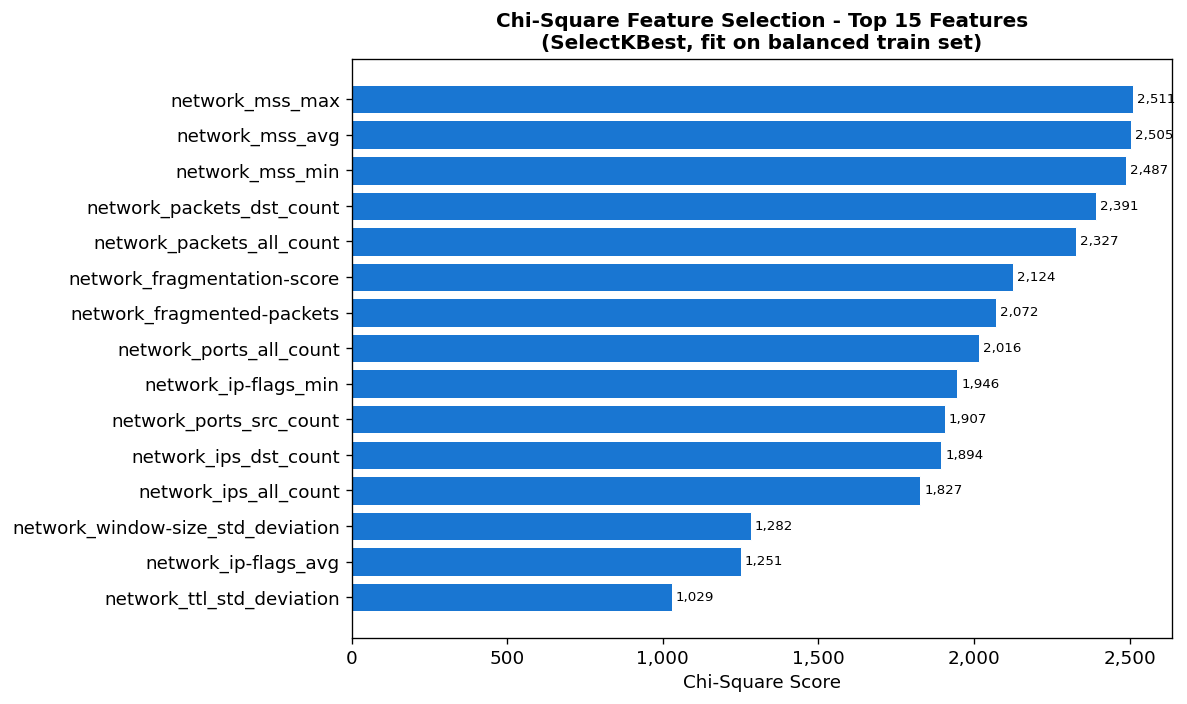

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sorted_names  = [chi_cols[i] for i in chi_order]
sorted_scores = [chi_scores[i] for i in chi_order]

bars = ax.barh(sorted_names[::-1], sorted_scores[::-1],
               color='#1976D2', edgecolor='white', linewidth=0.6)

ax.set_xlabel('Chi-Square Score', fontsize=11)
ax.set_title(f'Chi-Square Feature Selection - Top {K_FEATURES} Features\n'
             f'(SelectKBest, fit on balanced train set)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar, score in zip(bars, sorted_scores[::-1]):
    ax.text(bar.get_width() + sorted_scores[0]*0.005, bar.get_y() + bar.get_height()/2,
            f'{score:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('chi_square_features.png', bbox_inches='tight')
plt.show()

### 6.2 PCA - Explained Variance & Feature Selection

We first visualize how many principal components are needed to capture most of the dataset's variance (the scree plot), then apply the author's PCA-guided selection method.

**This is not standard PCA dimensionality reduction.** No data gets projected into a lower-dimensional space. Instead:
1. Fit `PCA(n_components=15)` on the scaled training data
2. For each of the 15 components, find the single original feature with the largest loading; the one that contributes most to that component (`argmax` of absolute loadings)
3. Use those named original features as the selected set (deduplicating if the same feature dominates multiple components)

The result is still 15 interpretable, named features from the original dataset, not abstract principal components. This approach uses PCA's variance-decomposition to *guide* feature selection, rather than to *replace* the original features.

In [18]:
# PCA fitted on StandardScaler output (balanced train)
n_components_full = min(len(feature_cols), X_train_bal_scaled.shape[0])
pca_full = PCA(n_components=min(30, n_components_full), random_state=RANDOM_STATE)
pca_full.fit(X_train_bal_scaled)

explained        = pca_full.explained_variance_ratio_
cumulative       = np.cumsum(explained)
n_for_95         = np.searchsorted(cumulative, 0.95) + 1
n_for_99         = np.searchsorted(cumulative, 0.99) + 1

print(f'Components to explain 95% variance: {n_for_95}')
print(f'Components to explain 99% variance: {n_for_99}')
print()
print(f'Variance captured by first {K_FEATURES} components: {cumulative[K_FEATURES-1]*100:.1f}%')

Components to explain 95% variance: 24
Components to explain 99% variance: 31

Variance captured by first 15 components: 86.7%


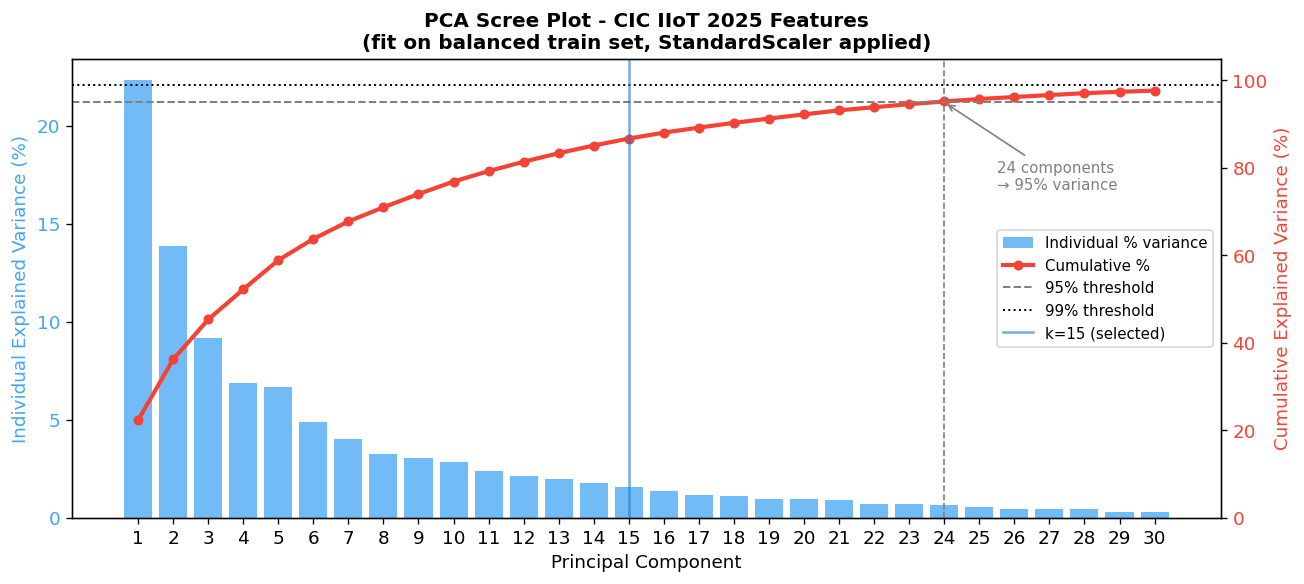

In [19]:
fig, ax1 = plt.subplots(figsize=(11, 5))

x_vals = np.arange(1, len(explained) + 1)

ax1.bar(x_vals, explained * 100, color='#42A5F5', alpha=0.75, label='Individual % variance')
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Individual Explained Variance (%)', fontsize=11, color='#42A5F5')
ax1.tick_params(axis='y', labelcolor='#42A5F5')

ax2 = ax1.twinx()
ax2.plot(x_vals, cumulative * 100, color='#F44336', linewidth=2.5,
         marker='o', markersize=5, label='Cumulative %')
ax2.axhline(95, color='gray', linestyle='--', linewidth=1.2, label='95% threshold')
ax2.axhline(99, color='black', linestyle=':', linewidth=1.2, label='99% threshold')
ax2.axvline(n_for_95, color='gray', linestyle='--', linewidth=1)
ax2.axvline(K_FEATURES, color='#1976D2', linestyle='-', linewidth=1.5, alpha=0.6,
            label=f'k={K_FEATURES} (selected)')
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=11, color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')
ax2.set_ylim(0, 105)

ax2.annotate(f'{n_for_95} components\n→ 95% variance',
             xy=(n_for_95, 95), xytext=(n_for_95 + 1.5, 75),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)

ax1.set_title('PCA Scree Plot - CIC IIoT 2025 Features\n'
              '(fit on balanced train set, StandardScaler applied)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_vals)

plt.tight_layout()
plt.savefig('pca_scree_plot.png', bbox_inches='tight')
plt.show()

In [20]:
# PCA-guided feature selection (author's method): argmax of absolute loadings per PC
pca_sel = PCA(n_components=K_FEATURES, random_state=RANDOM_STATE)
pca_sel.fit(X_train_bal_scaled)

absolute_loadings  = np.abs(pca_sel.components_)           # shape (15, n_features)
most_dominant_idx  = np.argmax(absolute_loadings, axis=1)  # one index per PC
pca_cols_raw       = np.array(feature_cols)[most_dominant_idx]

# Deduplicate while preserving PC order
seen, pca_cols = set(), []
for col in pca_cols_raw:
    if col not in seen:
        seen.add(col)
        pca_cols.append(col)

print(f'PCA-guided selection: {len(pca_cols)} unique features from {K_FEATURES} PCs')
print('Selected feature names (deduplicated):')
for i, c in enumerate(pca_cols, 1):
    print(f'  {i:2d}. {c}')

PCA-guided selection: 11 unique features from 15 PCs
Selected feature names (deduplicated):
   1. network_ips_src_count
   2. network_payload-length_avg
   3. network_packets_all_count
   4. network_ips_dst_count
   5. network_ip-flags_min
   6. log_data-ranges_std_deviation
   7. network_packets_src_count
   8. network_tcp-flags_std_deviation
   9. network_window-size_min
  10. network_tcp-flags-syn_count
  11. network_ports_dst_count


### 6.3 Random Forest Feature Importance (RFR)

A `RandomForestClassifier` is trained on the balanced training data (unscaled as RF doesn't need it). After training, `feature_importances_` gives each feature a Gini importance score: roughly, how much that feature reduced prediction error across all 100 trees.

The top 15 by importance are selected. The bar chart is color-coded by feature type (TCP flags, packet size, timing, etc.) to make the results easier to read and discuss. This method is supervised but leakage-resistant in practice. The top-15 ranking barely changes with or without the 20% test set, because the dominant signals are far stronger than any noise the test set introduces.

In [21]:
print('Training Random Forest selector on balanced train set...')
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_selector.fit(X_train_bal_raw, y_train_bal)

importances = rf_selector.feature_importances_
top_idx     = np.argsort(importances)[::-1][:K_FEATURES]
rfr_cols    = np.array(feature_cols)[top_idx].tolist()
rfr_scores  = importances[top_idx]

print(f'\nTop {K_FEATURES} features by Random Forest Gini importance:')
for rank, (col, score) in enumerate(zip(rfr_cols, rfr_scores), 1):
    print(f'  {rank:2d}. {col:<45}  importance={score:.6f}')

Training Random Forest selector on balanced train set...

Top 15 features by Random Forest Gini importance:
   1. network_packets_all_count                      importance=0.047661
   2. network_packets_dst_count                      importance=0.046091
   3. network_window-size_std_deviation              importance=0.045582
   4. network_time-delta_min                         importance=0.045154
   5. network_time-delta_avg                         importance=0.040229
   6. network_time-delta_std_deviation               importance=0.033909
   7. network_interval-packets                       importance=0.029197
   8. network_tcp-flags_std_deviation                importance=0.028301
   9. network_ports_all_count                        importance=0.027936
  10. network_ip-flags_avg                           importance=0.027014
  11. network_window-size_min                        importance=0.026576
  12. network_time-delta_max                         importance=0.026206
  13. network_ip

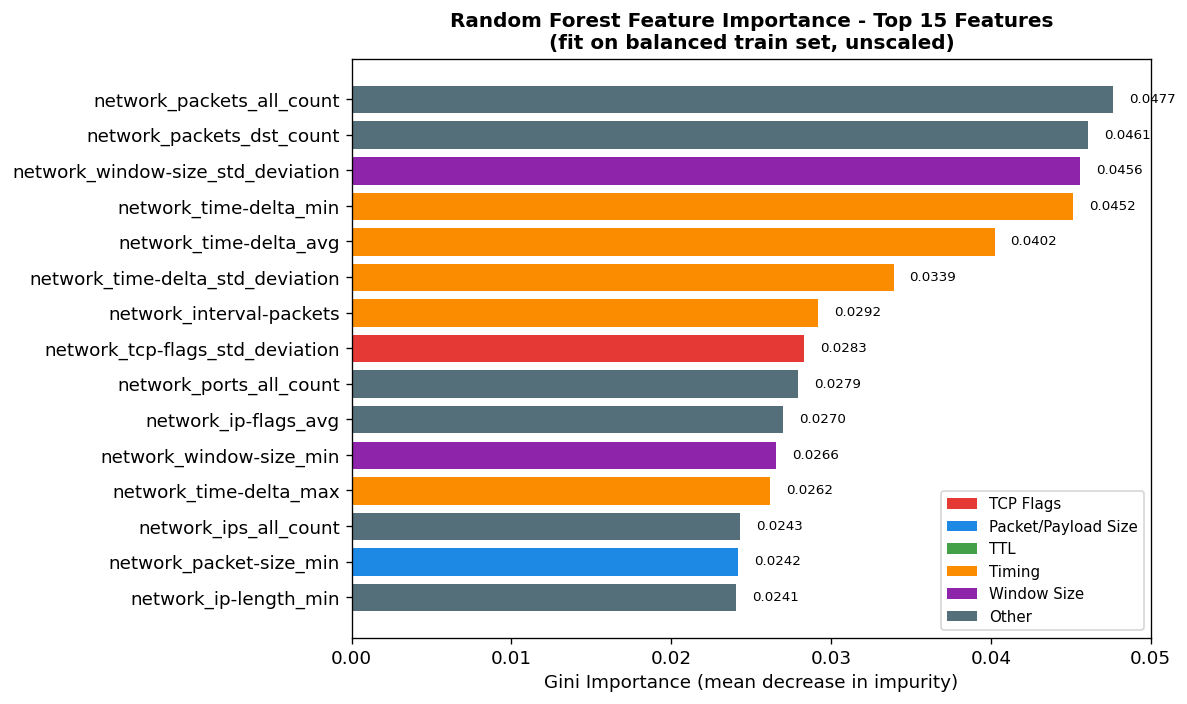

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Color bars by feature group
def feat_color(name):
    if 'tcp-flags' in name: return '#E53935'
    if 'packet-size' in name or 'payload' in name: return '#1E88E5'
    if 'ttl' in name: return '#43A047'
    if 'time-delta' in name or 'interval' in name: return '#FB8C00'
    if 'window' in name: return '#8E24AA'
    return '#546E7A'

colors = [feat_color(c) for c in rfr_cols[::-1]]
bars = ax.barh(rfr_cols[::-1], rfr_scores[::-1], color=colors, edgecolor='white', linewidth=0.6)

ax.set_xlabel('Gini Importance (mean decrease in impurity)', fontsize=11)
ax.set_title(f'Random Forest Feature Importance - Top {K_FEATURES} Features\n'
             f'(fit on balanced train set, unscaled)', fontsize=12, fontweight='bold')

for bar, score in zip(bars, rfr_scores[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', label='TCP Flags'),
    Patch(facecolor='#1E88E5', label='Packet/Payload Size'),
    Patch(facecolor='#43A047', label='TTL'),
    Patch(facecolor='#FB8C00', label='Timing'),
    Patch(facecolor='#8E24AA', label='Window Size'),
    Patch(facecolor='#546E7A', label='Other'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('rfr_feature_importance.png', bbox_inches='tight')
plt.show()

## 7. Pipeline Summary

Everything below is printed automatically from the variables computed above. This gives a single-screen overview of the full pipeline. Useful for verifying the numbers are consistent before moving on to classifier training.

In [23]:
print('=' * 60)
print('PIPELINE SUMMARY - CIC IIoT 2025 (1-second window)')
print('=' * 60)
print(f'  Total rows loaded          : {len(df):,}')
print(f'  Numeric features (X)       : {len(feature_cols)}')
print(f'  String metadata dropped    : {len(meta_cols)}')
print(f'  Missing values             : 0')
print(f'  Duplicates removed         : 0')
print()
print(f'  Train set (80%)            : {X_train_raw.shape[0]:,} rows')
print(f'  Test set  (20%)            : {X_test_raw.shape[0]:,} rows')
print(f'  Train set after balancing  : {X_train_bal_scaled.shape[0]:,} rows')
print(f'  Minority class count       : {n_min:,} ({le.classes_[pd.Series(y_train).value_counts().idxmin()]})')
print()
print(f'  k features selected        : {K_FEATURES}\n')
print(f'  Chi-Square features        : {chi_cols}\n')
print(f'  PCA-guided features        : {pca_cols}\n')
print(f'  RFR features               : {rfr_cols}\n')
print()
print(f'  PCA: {K_FEATURES} components explain {cumulative[K_FEATURES-1]*100:.1f}% variance')
print(f'  PCA: {n_for_95} components needed for 95% variance')
print('=' * 60)

PIPELINE SUMMARY - CIC IIoT 2025 (1-second window)
  Total rows loaded          : 227,191
  Numeric features (X)       : 71
  String metadata dropped    : 21
  Missing values             : 0
  Duplicates removed         : 0

  Train set (80%)            : 181,752 rows
  Test set  (20%)            : 45,439 rows
  Train set after balancing  : 11,952 rows
  Minority class count       : 1,494 (bruteforce)

  k features selected        : 15

  Chi-Square features        : ['network_fragmentation-score', 'network_fragmented-packets', 'network_ip-flags_avg', 'network_ip-flags_min', 'network_ips_all_count', 'network_ips_dst_count', 'network_mss_avg', 'network_mss_max', 'network_mss_min', 'network_packets_all_count', 'network_packets_dst_count', 'network_ports_all_count', 'network_ports_src_count', 'network_ttl_std_deviation', 'network_window-size_std_deviation']

  PCA-guided features        : [np.str_('network_ips_src_count'), np.str_('network_payload-length_avg'), np.str_('network_packets_al